In [1]:
import json
import os
import random

import numpy as np
import pandas as pd
from pathlib import Path
from PIL import Image

import torch
from torch import nn
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
from torchvision.models import resnet50
from tqdm.auto import tqdm

In [2]:
device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"device: {device}")

device: cuda


In [3]:
SEED = 42


def seed_everything(seed=SEED):
    """Fija todas las fuentes de aleatoriedad del notebook.

    Cubre la init de la cabeza, el shuffle del DataLoader y la
    RandomRotation del train_transform (que usa el RNG global de torch
    porque el DataLoader corre con num_workers=0).
    """
    os.environ["PYTHONHASHSEED"] = str(seed)
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    # Determinismo en cuDNN: reproducible a costa de algo de velocidad.
    # Con benchmark=True cuDNN elige algoritmos según el hardware y la
    # misma semilla deja de dar el mismo resultado entre máquinas.
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False


seed_everything()
print(f"Semilla fijada: {SEED} (cudnn.deterministic=True, benchmark=False)")

Semilla fijada: 42 (cudnn.deterministic=True, benchmark=False)


In [4]:
# Control: linear probe con backbone congelado (ancla con exp07, ahora sembrado).
EXP_ID = "exp10"
RUN_NAME = "exp10_resnet50_radimagenet_mammobench_frozen_linearhead_seed42"
UNFROZEN_DESC = "backbone completamente congelado"
BLOCK = 4
HEAD = "linear"

# LR de la cabeza (init aleatoria: necesita pasos grandes).
LR = 1e-3
# LR de los bloques descongelados del backbone. None = backbone
# congelado, no hay grupo de parámetros que optimizar.
LR_BACKBONE = None
WEIGHT_DECAY = 1e-4
BATCH_SIZE = 32
NUM_EPOCHS = 100
PATIENCE = 20
IMAGE_SIZE = 224
ROTATION_DEGREES = 10

PROJECT_ROOT = Path(
    "/media/imagenesmedicas/DATA1/01-ImagenesMedicas-US1/13-PregradoJulian/"
    "Federal Learning/infraestructura federada/Federal-Learning"
)

DATASET_ROOT = Path(
    "/media/imagenesmedicas/DATA1/01-ImagenesMedicas-US1/02-Databases/Mammo-Bench/"
    "c86fb00c-0fb8-4e0e-85a2-4d415f9c1ada_1a9410d8-9769-4064-a064-0160f2fd193d_"
    "DATASET-FILE_Mammo_Bench_zip_20241225112148174/Mammo_Data/Mammo-Bench"
)
MANIFEST_PATH = PROJECT_ROOT / "manifests" / "fedmammobench.csv"
RADIMAGENET_WEIGHTS_PATH = PROJECT_ROOT / "weights" / "RadImageNet-resnet50.pth"

RUN_DIR = PROJECT_ROOT / "runs" / RUN_NAME
PLOTS_DIR = RUN_DIR / "plots"
RUN_DIR.mkdir(parents=True, exist_ok=True)
PLOTS_DIR.mkdir(parents=True, exist_ok=True)

BEST_MODEL_PATH = RUN_DIR / "best_model.pth"
LAST_MODEL_PATH = RUN_DIR / "last_model.pth"

print(f"RUN_DIR: {RUN_DIR}")
print(f"LR cabeza: {LR} | LR backbone: {LR_BACKBONE}")

RUN_DIR: /media/imagenesmedicas/DATA1/01-ImagenesMedicas-US1/13-PregradoJulian/Federal Learning/infraestructura federada/Federal-Learning/runs/exp10_resnet50_radimagenet_mammobench_frozen_linearhead_seed42
LR cabeza: 0.001 | LR backbone: None


In [5]:
SPLIT_COL = "split"
LABEL_COL = "classification"
PATH_COL = "preprocessed_image_path"

TRAIN_SPLIT, VAL_SPLIT, TEST_SPLIT = "train", "val", "test"


class CSVDataset(Dataset):
    def __init__(self, csv_file, split, root_dir="", transform=None, label_to_idx=None):
        self.data = pd.read_csv(csv_file)

        missing = {SPLIT_COL, LABEL_COL, PATH_COL} - set(self.data.columns)
        if missing:
            raise KeyError(
                f"El manifest {csv_file} no tiene la(s) columna(s) {sorted(missing)}. "
                f"Columnas disponibles: {list(self.data.columns)}"
            )

        available = sorted(self.data[SPLIT_COL].dropna().unique())
        if split not in available:
            raise ValueError(
                f"split={split!r} no existe en la columna {SPLIT_COL!r}. "
                f"Valores disponibles: {available}"
            )

        self.data = self.data[self.data[SPLIT_COL] == split].reset_index(drop=True)
        if len(self.data) == 0:
            raise ValueError(f"El split {split!r} quedó vacío tras filtrar {csv_file}.")

        self.root_dir = Path(root_dir)
        self.transform = transform

        if label_to_idx is None:
            labels = sorted(self.data[LABEL_COL].unique())
            self.label_to_idx = {label: i for i, label in enumerate(labels)}
        else:
            self.label_to_idx = label_to_idx

        unknown = set(self.data[LABEL_COL].unique()) - set(self.label_to_idx)
        if unknown:
            raise ValueError(
                f"El split {split!r} tiene etiquetas {sorted(unknown)} ausentes en "
                f"label_to_idx={self.label_to_idx}."
            )

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        row = self.data.iloc[idx]

        img_path = Path(self.root_dir) / Path(row[PATH_COL])
        image = Image.open(img_path).convert("RGB")

        label = self.label_to_idx[row[LABEL_COL]]

        if self.transform:
            image = self.transform(image)

        return image, label

In [6]:
_manifest = pd.read_csv(MANIFEST_PATH)

_required = {SPLIT_COL, LABEL_COL, PATH_COL}
assert _required <= set(_manifest.columns), (
    f"Faltan columnas en el manifest: {sorted(_required - set(_manifest.columns))}"
)

_splits = sorted(_manifest[SPLIT_COL].dropna().unique())
assert set(_splits) >= {TRAIN_SPLIT, VAL_SPLIT, TEST_SPLIT}, (
    f"El manifest solo tiene splits {_splits}; se esperaban "
    f"{[TRAIN_SPLIT, VAL_SPLIT, TEST_SPLIT]}"
)

print(f"Filas totales: {len(_manifest)}\n")
print(pd.crosstab(_manifest[SPLIT_COL], _manifest[LABEL_COL], margins=True))

if "source_dataset" in _manifest.columns:
    print()
    print(pd.crosstab(_manifest["source_dataset"], _manifest[SPLIT_COL], margins=True))

Filas totales: 8821



classification  Benign  Malignant   All
split                                  
test               425        455   880
train             3356       3701  7057
val                421        463   884
All               4202       4619  8821

split           test  train  val   All
source_dataset                        
cdd-cesm         100    803  100  1003
cmmd             518   4162  522  5202
inbreast          40    328   42   410
kau-bcmd         222   1764  220  2206
All              880   7057  884  8821


In [7]:
train_transform = transforms.Compose([
    transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
    transforms.RandomRotation(ROTATION_DEGREES),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.5, 0.5, 0.5],
        std=[0.5, 0.5, 0.5]
    )
])

val_transform = transforms.Compose([
    transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.5, 0.5, 0.5],
        std=[0.5, 0.5, 0.5]
    )
])

In [8]:
train_processed = CSVDataset(
    csv_file=MANIFEST_PATH, split=TRAIN_SPLIT, root_dir=DATASET_ROOT,
    transform=train_transform,
)
validation_processed = CSVDataset(
    csv_file=MANIFEST_PATH, split=VAL_SPLIT, root_dir=DATASET_ROOT,
    transform=val_transform, label_to_idx=train_processed.label_to_idx,
)
test_processed = CSVDataset(
    csv_file=MANIFEST_PATH, split=TEST_SPLIT, root_dir=DATASET_ROOT,
    transform=val_transform, label_to_idx=train_processed.label_to_idx,
)

print(f"label_to_idx: {train_processed.label_to_idx}")
print(f"train: {len(train_processed)} | val: {len(validation_processed)} | test: {len(test_processed)}")

label_to_idx: {'Benign': 0, 'Malignant': 1}
train: 7057 | val: 884 | test: 880


In [9]:
# El shuffle del DataLoader consume el RNG global de torch; con un generator
# propio sembrado el orden de los batches es el mismo en cada ejecución
# aunque se re-ejecuten celdas de arriba en otro orden.
_loader_generator = torch.Generator()
_loader_generator.manual_seed(SEED)


def _seed_worker(worker_id):
    worker_seed = torch.initial_seed() % 2**32
    np.random.seed(worker_seed)
    random.seed(worker_seed)


train = DataLoader(
    train_processed, batch_size=BATCH_SIZE, shuffle=True,
    generator=_loader_generator, worker_init_fn=_seed_worker,
)
validation = DataLoader(validation_processed, batch_size=BATCH_SIZE, shuffle=False)
test = DataLoader(test_processed, batch_size=BATCH_SIZE, shuffle=False)

In [10]:
class Classifier(nn.Module):
    def __init__(self, num_class):
        super().__init__()
        self.linear = nn.Linear(2048, num_class)

    def forward(self, x):
        x = x.view(x.size(0), -1)
        return self.linear(x)


class Backbone(nn.Module):
    def __init__(self):
        super().__init__()
        base_model = resnet50(weights=None)
        encoder_layers = list(base_model.children())
        self.backbone = nn.Sequential(*encoder_layers[:9])

    def forward(self, x):
        return self.backbone(x)

In [11]:
seed_everything()  # pesos iniciales de la cabeza reproducibles

classifier = Classifier(num_class=2).to(device)
print("Clasificador lineal 2048->2")
print(f"Parámetros del clasificador: {sum(p.numel() for p in classifier.parameters()):,}")

Clasificador lineal 2048->2
Parámetros del clasificador: 4,098


In [12]:
def load_radimagenet_backbone(weights_path, device="cpu"):
    model = resnet50(weights=None)
    checkpoint = torch.load(weights_path, map_location=device)

    if isinstance(checkpoint, dict) and "state_dict" in checkpoint:
        state_dict = checkpoint["state_dict"]
    else:
        state_dict = checkpoint

    state_dict = {k.replace("module.", ""): v for k, v in state_dict.items()}

    # RadImageNet-resnet50.pth guarda el backbone como nn.Sequential, así que
    # sus claves son "backbone.0.weight" en vez de "conv1.weight". Sin este
    # remap, load_state_dict(strict=False) casa CERO claves y deja el modelo
    # en su init aleatorio sin avisar.
    backbone_remap = {
        "backbone.0.": "conv1.",
        "backbone.1.": "bn1.",
        "backbone.4.": "layer1.",
        "backbone.5.": "layer2.",
        "backbone.6.": "layer3.",
        "backbone.7.": "layer4.",
    }
    remapped_state_dict = {}
    for k, v in state_dict.items():
        new_k = k
        for old_prefix, new_prefix in backbone_remap.items():
            if k.startswith(old_prefix):
                new_k = new_prefix + k[len(old_prefix):]
                break
        remapped_state_dict[new_k] = v
    state_dict = remapped_state_dict

    state_dict = {
        k: v for k, v in state_dict.items()
        if k.startswith(("conv1", "bn1", "relu", "maxpool", "layer1", "layer2", "layer3", "layer4", "avgpool"))
    }

    if len(state_dict) == 0:
        raise RuntimeError(
            "0 RadImageNet tensors matched the model after remapping — "
            "check the checkpoint's key format before continuing."
        )

    missing, unexpected = model.load_state_dict(state_dict, strict=False)
    print(f"Loaded {len(state_dict)} RadImageNet tensors into the backbone.")
    print("Missing keys:", missing)
    print("Unexpected keys:", unexpected)

    # Trunca a conv1..avgpool para que la salida (batch, 2048, 1, 1) encaje
    # con el Linear(2048, ...) del clasificador.
    encoder_layers = list(model.children())
    return nn.Sequential(*encoder_layers[:9])


backbone = load_radimagenet_backbone(RADIMAGENET_WEIGHTS_PATH, device=device).to(device)

Loaded 318 RadImageNet tensors into the backbone.
Missing keys: ['fc.weight', 'fc.bias']
Unexpected keys: []


In [13]:
for param in backbone.parameters():
    param.requires_grad = False


trainable = sum(p.numel() for p in backbone.parameters() if p.requires_grad)
total = sum(p.numel() for p in backbone.parameters())
pct = 100 * trainable / total
print(f"[{EXP_ID}] Backbone trainable params: {trainable:,} / {total:,} ({pct:.2f}%)")

[exp10] Backbone trainable params: 0 / 23,508,032 (0.00%)


In [14]:
train_loss_history = []
val_loss_history = []


def freeze_bn_running_stats(module):
    # requires_grad=False congela gamma/beta pero NO running_mean/running_var,
    # que se siguen actualizando en cada forward en modo train(). eval() las fija.
    for m in module.modules():
        if isinstance(m, nn.BatchNorm2d) and not m.weight.requires_grad:
            m.eval()


def train_model(model, criterion, optimizer, num_epochs=NUM_EPOCHS, sheduler=None,
                patience=PATIENCE):
    min_valid_loss = np.inf
    train_loss_history.clear()
    val_loss_history.clear()
    counter = 0
    best_epoch = 0

    epoch_bar = tqdm(range(num_epochs), desc="Epochs", unit="epoch")
    for e in epoch_bar:
        train_loss = 0.0
        model.train()
        freeze_bn_running_stats(model)
        train_bar = tqdm(train, desc=f"  train {e+1}/{num_epochs}", unit="batch", leave=False)
        for data, labels in train_bar:
            data, labels = data.to(device, dtype=torch.float), labels.to(device)

            optimizer.zero_grad()
            target = model(data)
            loss = criterion(target, labels)
            loss.backward()
            optimizer.step()
            train_loss += loss.item()
            train_bar.set_postfix(loss=f"{loss.item():.4f}")

        valid_loss = 0.0
        model.eval()
        val_bar = tqdm(validation, desc=f"  val   {e+1}/{num_epochs}", unit="batch", leave=False)
        with torch.no_grad():
            for data, labels in val_bar:
                data, labels = data.to(device, dtype=torch.float), labels.to(device)

                target = model(data)
                loss = criterion(target, labels)
                valid_loss += loss.item()
                val_bar.set_postfix(loss=f"{loss.item():.4f}")

        avg_train_loss = train_loss / len(train)
        avg_valid_loss = valid_loss / len(validation)
        train_loss_history.append(avg_train_loss)
        val_loss_history.append(avg_valid_loss)
        epoch_bar.set_postfix(train_loss=f"{avg_train_loss:.4f}", val_loss=f"{avg_valid_loss:.4f}")

        print(f"Epoch {e+1} \t\t Training Loss: {avg_train_loss} \t\t Validation Loss: {avg_valid_loss}")

        torch.save(model.state_dict(), LAST_MODEL_PATH)

        if min_valid_loss > avg_valid_loss:
            print(f"Validation Loss Decreased({min_valid_loss:.6f}--->{avg_valid_loss:.6f}) \t Saving The Model")
            min_valid_loss = avg_valid_loss
            best_epoch = e + 1
            torch.save(model.state_dict(), BEST_MODEL_PATH)
            counter = 0
        else:
            counter += 1
            print(f"EarlyStopping counter: {counter} out of {patience}")

        if counter >= patience:
            print(f"Early stopping triggered en la época {e+1}. Mejor época: {best_epoch}.")
            break

        if sheduler is not None:
            sheduler.step()

    print(f"\nMejor época: {best_epoch} (val loss {min_valid_loss:.6f}) -> {BEST_MODEL_PATH}")
    print(f"Última época: {len(train_loss_history)} -> {LAST_MODEL_PATH}")
    return model

In [15]:
class FullModel(nn.Module):
    def __init__(self, backbone, classifier):
        super().__init__()
        self.backbone = backbone
        self.classifier = classifier

    def forward(self, x):
        x = self.backbone(x)
        x = self.classifier(x)
        return x


model = FullModel(backbone, classifier).to(device)

In [16]:
criterion = nn.CrossEntropyLoss()

# LR diferencial: la cabeza parte de una init aleatoria y necesita 1e-3; el
# backbone trae pesos RadImageNet ya buenos y con ese mismo LR los destruye en
# 1-3 épocas (es lo que pasó en exp02/03/05/06/08/09). Grupos separados.
backbone_params = [p for p in model.backbone.parameters() if p.requires_grad]
head_params = [p for p in model.classifier.parameters() if p.requires_grad]

param_groups = [{"params": head_params, "lr": LR, "name": "head"}]
if backbone_params:
    assert LR_BACKBONE is not None, (
        "Hay parámetros de backbone descongelados pero LR_BACKBONE es None."
    )
    param_groups.append({"params": backbone_params, "lr": LR_BACKBONE, "name": "backbone"})
elif LR_BACKBONE is not None:
    raise ValueError(
        "LR_BACKBONE está fijado pero el backbone está completamente congelado."
    )

optimizer = torch.optim.AdamW(param_groups, lr=LR, weight_decay=WEIGHT_DECAY)
# CosineAnnealingLR guarda un base_lr por grupo y decae los dos en paralelo,
# así que el ratio cabeza/backbone se mantiene casi todo el run. Solo se
# comprime en las últimas épocas, cuando el grupo del backbone toca el suelo
# absoluto eta_min=1e-7 antes que el de la cabeza; a esa altura los dos LR son
# ~1e-7 y ya no mueven los pesos, así que no afecta al resultado.
sheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=NUM_EPOCHS, eta_min=1e-7)

print(f"Optimizer: AdamW(weight_decay={WEIGHT_DECAY})")
for g in optimizer.param_groups:
    n = sum(p.numel() for p in g["params"])
    print(f"  grupo {g['name']:9} lr={g['lr']:<8} params={n:,}")

Optimizer: AdamW(weight_decay=0.0001)
  grupo head      lr=0.001    params=4,098


In [17]:
model = train_model(model, criterion, optimizer, num_epochs=NUM_EPOCHS,
                    sheduler=sheduler, patience=PATIENCE)

Epochs:   0%|          | 0/100 [00:00<?, ?epoch/s]

  train 1/100:   0%|          | 0/221 [00:00<?, ?batch/s]

  val   1/100:   0%|          | 0/28 [00:00<?, ?batch/s]

Epoch 1 		 Training Loss: 0.5869883867949922 		 Validation Loss: 0.5306017068879945


Validation Loss Decreased(inf--->0.530602) 	 Saving The Model


...

EarlyStopping counter: 19 out of 20


  train 72/100:   0%|          | 0/221 [00:00<?, ?batch/s]

  val   72/100:   0%|          | 0/28 [00:00<?, ?batch/s]

Epoch 72 		 Training Loss: 0.4349465805076366 		 Validation Loss: 0.4450093800468104


EarlyStopping counter: 20 out of 20
Early stopping triggered en la época 72. Mejor época: 52.

Mejor época: 52 (val loss 0.443806) -> /media/imagenesmedicas/DATA1/01-ImagenesMedicas-US1/13-PregradoJulian/Federal Learning/infraestructura federada/Federal-Learning/runs/exp10_resnet50_radimagenet_mammobench_frozen_linearhead_seed42/best_model.pth
Última época: 72 -> /media/imagenesmedicas/DATA1/01-ImagenesMedicas-US1/13-PregradoJulian/Federal Learning/infraestructura federada/Federal-Learning/runs/exp10_resnet50_radimagenet_mammobench_frozen_linearhead_seed42/last_model.pth


Epoch   1 	 Training Loss: 0.586988 	 Validation Loss: 0.530602
Epoch   2 	 Training Loss: 0.538723 	 Validation Loss: 0.509321
Epoch   3 	 Training Loss: 0.524146 	 Validation Loss: 0.498395
Epoch   4 	 Training Loss: 0.513283 	 Validation Loss: 0.489043
Epoch   5 	 Training Loss: 0.505066 	 Validation Loss: 0.484289
Epoch   6 	 Training Loss: 0.501343 	 Validation Loss: 0.478046
Epoch   7 	 Training Loss: 0.496363 	 Validation Loss: 0.475628
Epoch   8 	 Training Loss: 0.492922 	 Validation Loss: 0.474477
Epoch   9 	 Training Loss: 0.487845 	 Validation Loss: 0.471666
Epoch  10 	 Training Loss: 0.486384 	 Validation Loss: 0.467786
Epoch  11 	 Training Loss: 0.483079 	 Validation Loss: 0.465576
Epoch  12 	 Training Loss: 0.480729 	 Validation Loss: 0.462233
Epoch  13 	 Training Loss: 0.475776 	 Validation Loss: 0.460179
Epoch  14 	 Training Loss: 0.476776 	 Validation Loss: 0.463389
Epoch  15 	 Training Loss: 0.472847 	 Validation Loss: 0.458168
Epoch  16 	 Training Loss: 0.471619 	 Va

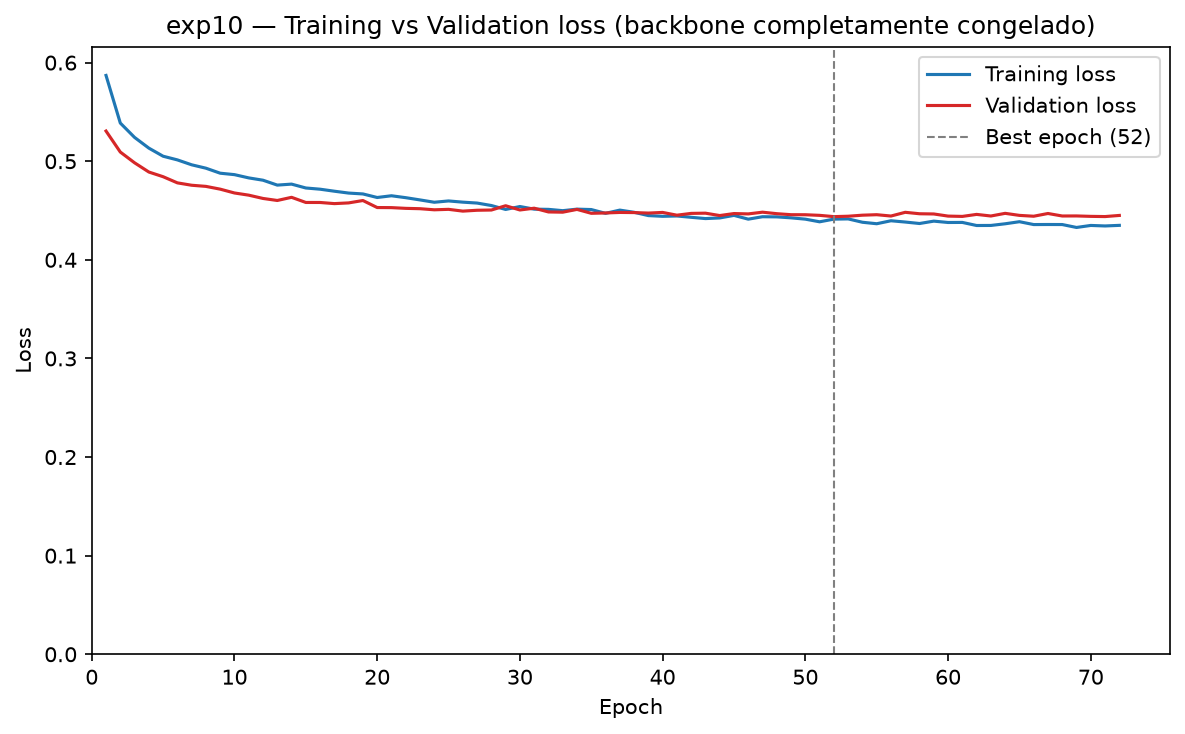

In [18]:
import matplotlib.pyplot as plt

best_epoch = int(np.argmin(val_loss_history)) + 1

for epoch, (t_loss, v_loss) in enumerate(zip(train_loss_history, val_loss_history), start=1):
    marker = "  <-- best (min val loss)" if epoch == best_epoch else ""
    print(f"Epoch {epoch:3d} \t Training Loss: {t_loss:.6f} \t Validation Loss: {v_loss:.6f}{marker}")

loss_history_path = RUN_DIR / "loss_history.csv"
pd.DataFrame({
    "epoch": range(1, len(train_loss_history) + 1),
    "train_loss": train_loss_history,
    "val_loss": val_loss_history,
}).to_csv(loss_history_path, index=False)
print(f"\nHistorial guardado en: {loss_history_path}")

fig, ax = plt.subplots(figsize=(8, 5))
epochs_range = range(1, len(train_loss_history) + 1)
ax.plot(epochs_range, train_loss_history, label="Training loss", color="#1f77b4")
ax.plot(epochs_range, val_loss_history, label="Validation loss", color="#d62728")
ax.axvline(best_epoch, linestyle="--", color="gray", lw=1, label=f"Best epoch ({best_epoch})")
ax.set_xlim(left=0)
ax.set_ylim(0, max(max(train_loss_history), max(val_loss_history)) * 1.05)
ax.set_xlabel("Epoch")
ax.set_ylabel("Loss")
ax.set_title(f"{EXP_ID} — Training vs Validation loss ({UNFROZEN_DESC})")
ax.legend()
fig.tight_layout()

loss_curve_path = PLOTS_DIR / "loss_curve.png"
fig.savefig(loss_curve_path, dpi=150, bbox_inches="tight")
print(f"Figura guardada en: {loss_curve_path}")
plt.show()

In [19]:
from sklearn.metrics import accuracy_score, roc_auc_score, classification_report

model.load_state_dict(torch.load(BEST_MODEL_PATH, map_location=device))
model.eval()

all_labels, all_preds, all_probs = [], [], []
with torch.no_grad():
    for data, labels in tqdm(test, desc="Test", unit="batch"):
        data = data.to(device, dtype=torch.float)
        logits = model(data)
        probs = torch.softmax(logits, dim=-1)[:, 1]
        preds = logits.argmax(dim=-1)

        all_labels.extend(labels.numpy())
        all_preds.extend(preds.cpu().numpy())
        all_probs.extend(probs.cpu().numpy())

test_acc = accuracy_score(all_labels, all_preds)
test_auc = roc_auc_score(all_labels, all_probs)

idx_to_label = {v: k for k, v in train_processed.label_to_idx.items()}
print(f"label_to_idx: {train_processed.label_to_idx}  (clase positiva para AUC = {idx_to_label[1]!r})")
print(f"Test accuracy: {test_acc:.4f}")
print(f"Test ROC AUC:  {test_auc:.4f}")
print()
print(classification_report(all_labels, all_preds, target_names=[idx_to_label[0], idx_to_label[1]]))

Test:   0%|          | 0/28 [00:00<?, ?batch/s]

label_to_idx: {'Benign': 0, 'Malignant': 1}  (clase positiva para AUC = 'Malignant')
Test accuracy: 0.7920
Test ROC AUC:  0.8357

              precision    recall  f1-score   support

      Benign       0.83      0.71      0.77       425
   Malignant       0.76      0.87      0.81       455

    accuracy                           0.79       880
   macro avg       0.80      0.79      0.79       880
weighted avg       0.80      0.79      0.79       880



Figura guardada en: /media/imagenesmedicas/DATA1/01-ImagenesMedicas-US1/13-PregradoJulian/Federal Learning/infraestructura federada/Federal-Learning/runs/exp10_resnet50_radimagenet_mammobench_frozen_linearhead_seed42/plots/test_confusion_matrix.png


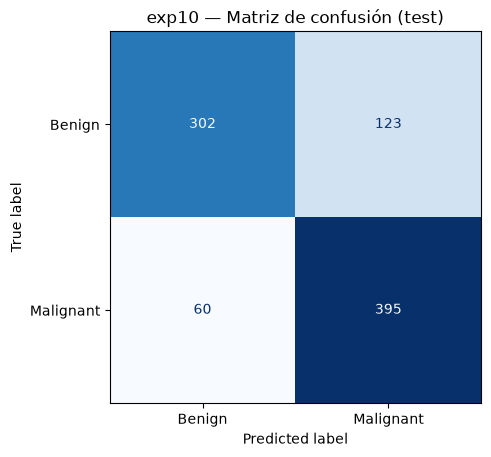

Accuracy  : 0.7920
ROC AUC   : 0.8357
Precision : 0.7625
Recall    : 0.8681
F1-score  : 0.8119


Figura guardada en: /media/imagenesmedicas/DATA1/01-ImagenesMedicas-US1/13-PregradoJulian/Federal Learning/infraestructura federada/Federal-Learning/runs/exp10_resnet50_radimagenet_mammobench_frozen_linearhead_seed42/plots/test_roc_curve.png


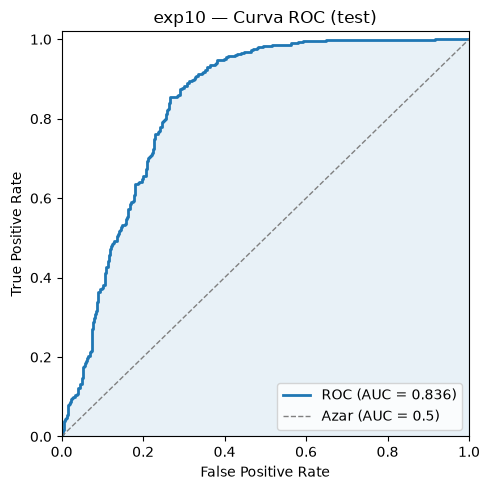

Figura guardada en: /media/imagenesmedicas/DATA1/01-ImagenesMedicas-US1/13-PregradoJulian/Federal Learning/infraestructura federada/Federal-Learning/runs/exp10_resnet50_radimagenet_mammobench_frozen_linearhead_seed42/plots/test_metrics_bar.png


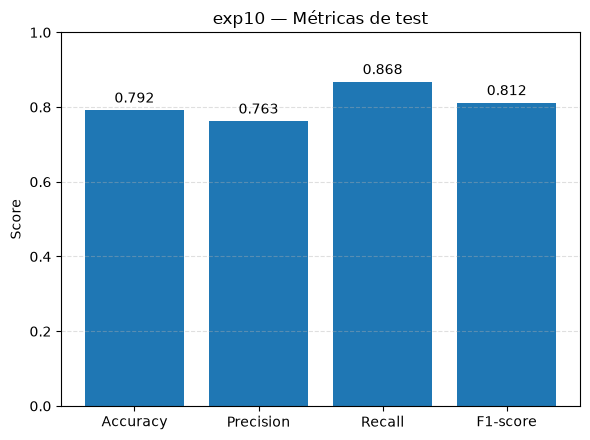

In [20]:
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, precision_score, recall_score, f1_score, roc_curve

test_precision = precision_score(all_labels, all_preds, pos_label=1)
test_recall = recall_score(all_labels, all_preds, pos_label=1)
test_f1 = f1_score(all_labels, all_preds, pos_label=1)
cm = confusion_matrix(all_labels, all_preds)

class_names = [idx_to_label[0], idx_to_label[1]]

fig_cm, ax_cm = plt.subplots(figsize=(5, 5))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names)
disp.plot(ax=ax_cm, cmap="Blues", colorbar=False, values_format="d")
ax_cm.set_title(f"{EXP_ID} — Matriz de confusión (test)")
fig_cm.tight_layout()

cm_path = PLOTS_DIR / "test_confusion_matrix.png"
fig_cm.savefig(cm_path, dpi=150, bbox_inches="tight")
print(f"Figura guardada en: {cm_path}")
plt.show()

metrics = {
    "Accuracy": test_acc,
    "ROC AUC": test_auc,
    "Precision": test_precision,
    "Recall": test_recall,
    "F1-score": test_f1,
}
for name, value in metrics.items():
    print(f"{name:10s}: {value:.4f}")

# ROC AUC es el area bajo la curva ROC: se grafica la curva real, no un punto suelto.
fpr, tpr, _ = roc_curve(all_labels, all_probs)

fig_roc, ax_roc = plt.subplots(figsize=(5, 5))
ax_roc.plot(fpr, tpr, color="#1f77b4", lw=2, label=f"ROC (AUC = {test_auc:.3f})")
ax_roc.fill_between(fpr, tpr, alpha=0.1, color="#1f77b4")
ax_roc.plot([0, 1], [0, 1], linestyle="--", color="gray", lw=1, label="Azar (AUC = 0.5)")
ax_roc.set_xlim(0, 1)
ax_roc.set_ylim(0, 1.02)
ax_roc.set_xlabel("False Positive Rate")
ax_roc.set_ylabel("True Positive Rate")
ax_roc.set_title(f"{EXP_ID} — Curva ROC (test)")
ax_roc.legend(loc="lower right")
fig_roc.tight_layout()

roc_path = PLOTS_DIR / "test_roc_curve.png"
fig_roc.savefig(roc_path, dpi=150, bbox_inches="tight")
print(f"Figura guardada en: {roc_path}")
plt.show()

# Accuracy/Precision/Recall/F1 son escalares puntuales en el mismo rango [0, 1]: se
# comparan mejor juntos en un solo grafico de barras que en 4 graficos de un punto.
bar_metrics = {k: v for k, v in metrics.items() if k != "ROC AUC"}

fig_bar, ax_bar = plt.subplots(figsize=(6, 4.5))
bars = ax_bar.bar(bar_metrics.keys(), bar_metrics.values(), color="#1f77b4")
ax_bar.set_ylim(0, 1)
ax_bar.set_ylabel("Score")
ax_bar.set_title(f"{EXP_ID} — Métricas de test")
ax_bar.grid(True, axis="y", linestyle="--", alpha=0.4)
ax_bar.bar_label(bars, fmt="%.3f", padding=3)
fig_bar.tight_layout()

bar_path = PLOTS_DIR / "test_metrics_bar.png"
fig_bar.savefig(bar_path, dpi=150, bbox_inches="tight")
print(f"Figura guardada en: {bar_path}")
plt.show()

In [21]:
summary = {
    "experiment": EXP_ID,
    "block": BLOCK,
    "run_name": RUN_NAME,
    "unfrozen": UNFROZEN_DESC,
    "seed": SEED,
    "hyperparams": {
        "head": HEAD,
        "dropout": DROPOUT if HEAD == "mlp" else None,
        "lr": LR,
        "lr_head": LR,
        "lr_backbone": LR_BACKBONE,
        "weight_decay": WEIGHT_DECAY,
        "batch_size": BATCH_SIZE,
        "num_epochs": NUM_EPOCHS,
        "patience": PATIENCE,
        "image_size": IMAGE_SIZE,
        "optimizer": "AdamW",
        "scheduler": "CosineAnnealingLR",
        "augmentation": f"RandomRotation({ROTATION_DEGREES})",
        "seed": SEED,
    },
    "epochs_run": len(train_loss_history),
    "best_epoch": best_epoch,
    "best_val_loss": float(min(val_loss_history)),
    "final_train_loss": float(train_loss_history[-1]),
    "final_val_loss": float(val_loss_history[-1]),
    "test": {
        "accuracy": float(test_acc),
        "auc": float(test_auc),
        "precision": float(test_precision),
        "recall": float(test_recall),
        "f1": float(test_f1),
        "confusion_matrix": cm.tolist(),
        "class_names": class_names,
    },
    "checkpoints": {
        "best": str(BEST_MODEL_PATH),
        "last": str(LAST_MODEL_PATH),
    },
}

metrics_path = RUN_DIR / "metrics.json"
metrics_path.write_text(json.dumps(summary, indent=2))
print(f"Resumen guardado en: {metrics_path}")
print(json.dumps(summary["test"], indent=2))

Resumen guardado en: /media/imagenesmedicas/DATA1/01-ImagenesMedicas-US1/13-PregradoJulian/Federal Learning/infraestructura federada/Federal-Learning/runs/exp10_resnet50_radimagenet_mammobench_frozen_linearhead_seed42/metrics.json
{
  "accuracy": 0.7920454545454545,
  "auc": 0.8356819650937298,
  "precision": 0.7625482625482626,
  "recall": 0.8681318681318682,
  "f1": 0.8119218910585817,
  "confusion_matrix": [
    [
      302,
      123
    ],
    [
      60,
      395
    ]
  ],
  "class_names": [
    "Benign",
    "Malignant"
  ]
}
